# IKE Asymmetry Fractions and Tendencies (Shear-Motion Orientation)

Two 2x2 violin-plot panels, both split by shear-motion orientation (Parallel /
Perp-Right / Anti-Parallel / Perp-Left):
1. **Fractions** -- what portion of a storm's total IKE sits in the down-motion,
   down-shear, right-of-motion, and right-of-shear half of the storm
2. **Tendencies** -- the 12-hour forward rate of change of each of those same
   four absolute IKE halves

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`. 

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["SHIPS_PATH"] = "/data/jacob.carstens/SHIPS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from ike_climatology import config
from ike_climatology.asymmetry_tendency import load_master_dataframe_tendency


## Data extraction

`load_master_dataframe_tendency` handles per-basin IBTrACS + SHIPS loading (skipping
any basin without SHIPS entirely), genesis-basin filtering, quadrant IKE computation,
shear matching + orientation categorization, the all-4-quadrants-positive quality
gate, shear-relative rotation, IKE fractions, and 12-hour forward tendencies.

In [3]:
master_df = load_master_dataframe_tendency(
    basins=config.BASINS_TO_ANALYZE,
    ibtracs_file_map=config.IBTRACS_FILE_MAP,
    ships_file_map=config.SHIPS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    ships_base_path=config.SHIPS_BASE_PATH,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH/SHIPS_PATH.")

year_range = (int(master_df["storm_year"].min()), int(master_df["storm_year"].max()))
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
print(f"{len(master_df)} qualifying timesteps, {master_df['storm_id'].nunique()} storms, "
      f"years {year_range[0]}-{year_range[1]}.")



--- Starting Global Processing (2004-2024) ---

Processing Basin: North Atlantic...
        - Filtered out 2 crossover/external storms based on official genesis basin label.

Processing Basin: East Pacific...
        - Filtered out 79 crossover/external storms based on official genesis basin label.

Processing Basin: West Pacific...
        - Filtered out 16 crossover/external storms based on official genesis basin label.

Processing Basin: North Indian...
        - Filtered out 13 crossover/external storms based on official genesis basin label.

Processing Basin: South Indian...
        - Filtered out 22 crossover/external storms based on official genesis basin label.

Processing Basin: South Pacific...
        - Filtered out 12 crossover/external storms based on official genesis basin label.

--- Compiling Global Master DataFrame ---
22826 qualifying timesteps, 1353 storms, years 2004-2023.


## Shared plot helper

Adds a per-orientation `n=` count to each panel's x-tick labels, based on the
specific column being plotted.

In [4]:
ORIENT_ORDER = ["Parallel", "Perp-Right", "Anti-Parallel", "Perp-Left"]


def annotate_orient_counts(ax, data, value_col, order=ORIENT_ORDER):
    counts = data.dropna(subset=[value_col])["shear_motion_orient"].value_counts()
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}\n(n={counts.get(o, 0)})" for o in order])


## Figure 1: Asymmetry fractions

/tmp/ipykernel_1036123/903755034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="shear_motion_orient", y="front_motion_frac", data=master_df,
/tmp/ipykernel_1036123/903755034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="shear_motion_orient", y="down_shear_frac", data=master_df,
/tmp/ipykernel_1036123/903755034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="shear_motion_orient", y="right_motion_frac", data=master_df,
/tmp/ipykernel_1036123/903755034.py:18: FutureWarning: 

Passing `palette` without assigning

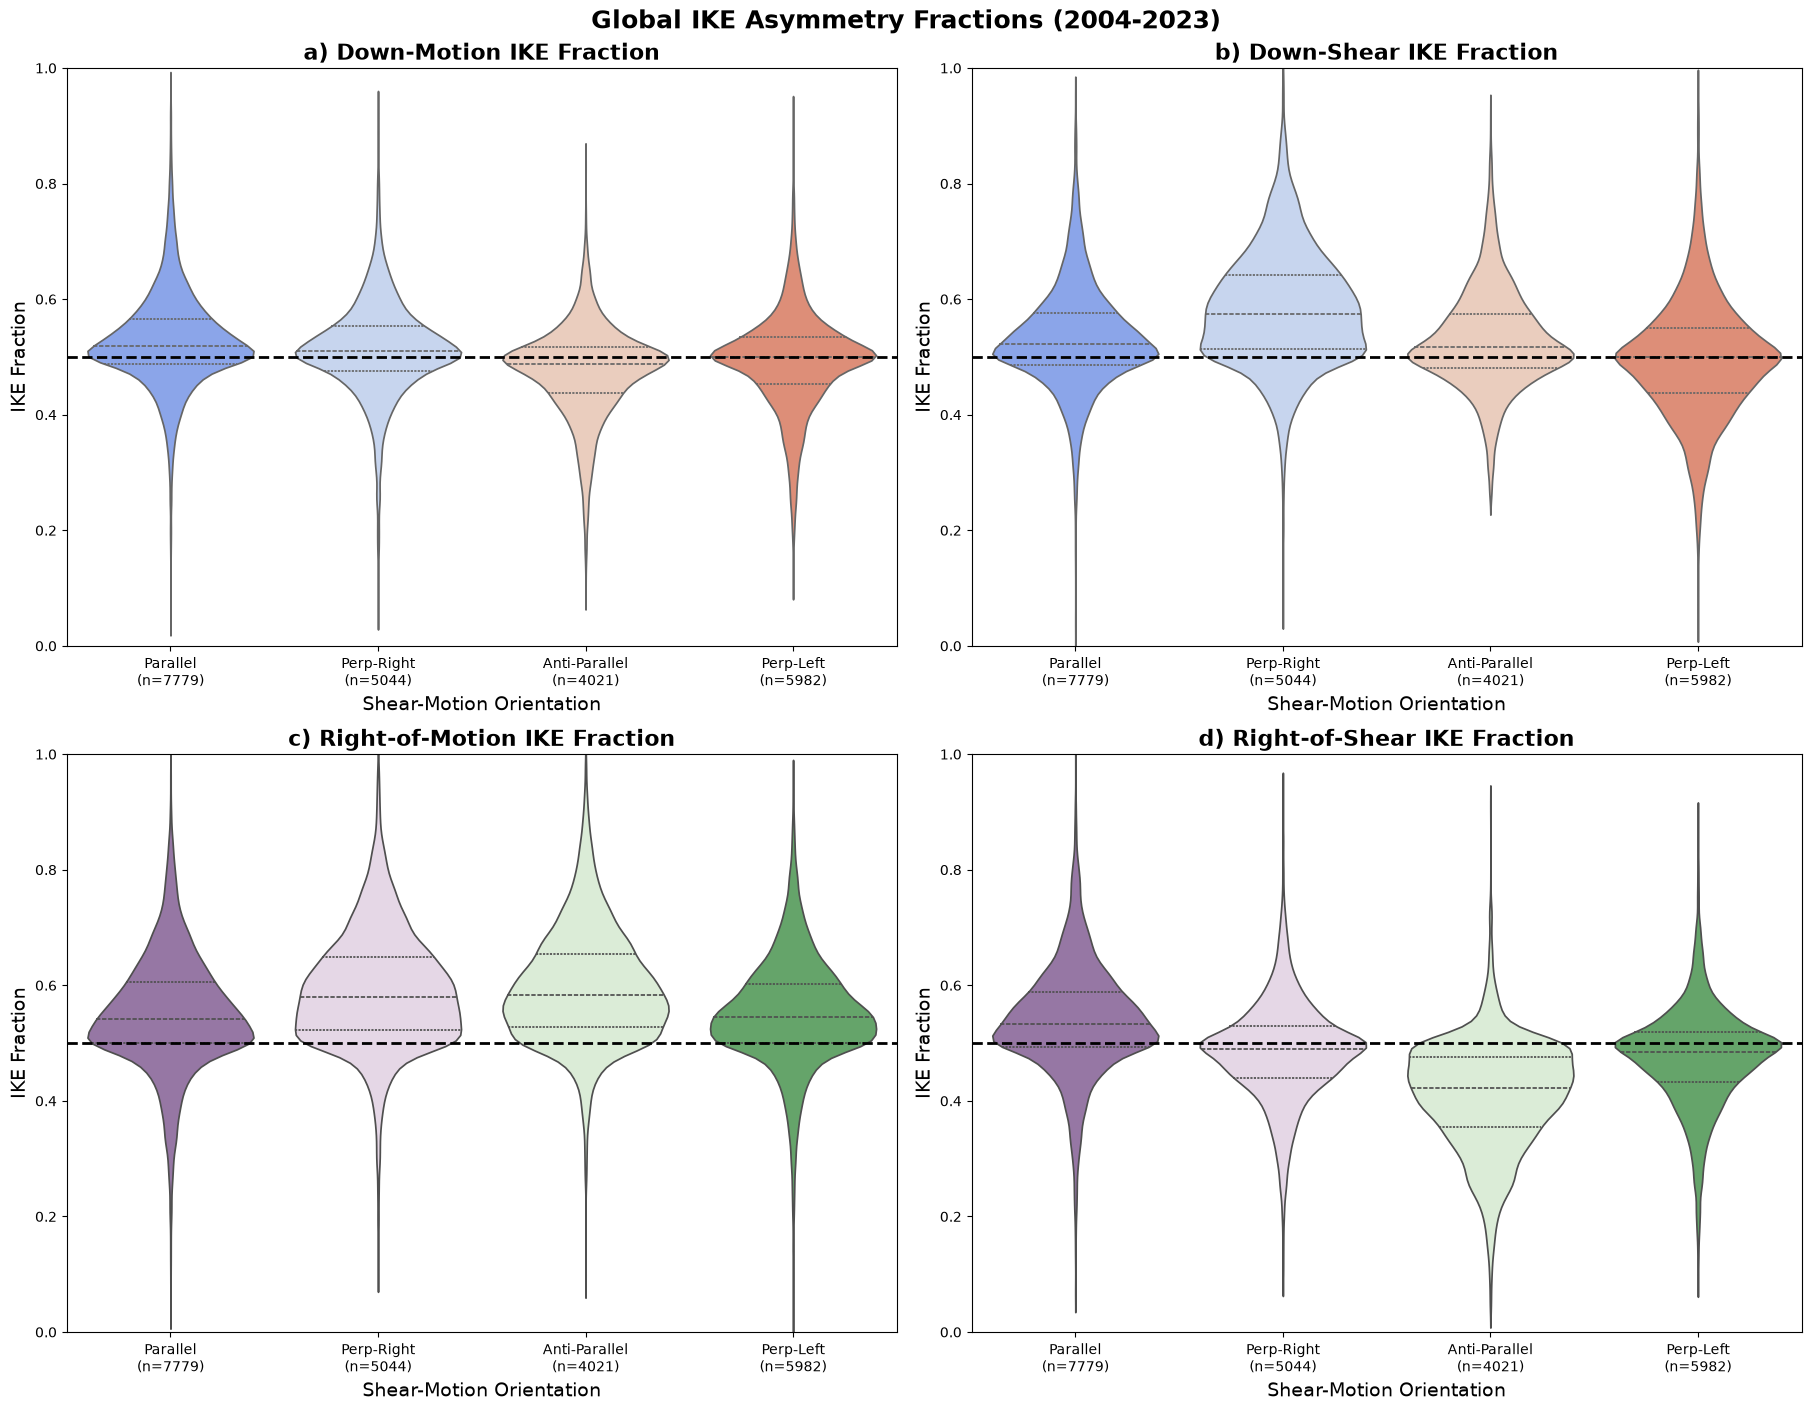

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)

sns.violinplot(x="shear_motion_orient", y="front_motion_frac", data=master_df,
               order=ORIENT_ORDER, palette="coolwarm", inner="quartile", ax=axes[0, 0])
axes[0, 0].set_title("a) Down-Motion IKE Fraction", weight="bold", fontsize=16)
annotate_orient_counts(axes[0, 0], master_df, "front_motion_frac")

sns.violinplot(x="shear_motion_orient", y="down_shear_frac", data=master_df,
               order=ORIENT_ORDER, palette="coolwarm", inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("b) Down-Shear IKE Fraction", weight="bold", fontsize=16)
annotate_orient_counts(axes[0, 1], master_df, "down_shear_frac")

sns.violinplot(x="shear_motion_orient", y="right_motion_frac", data=master_df,
               order=ORIENT_ORDER, palette="PRGn", inner="quartile", ax=axes[1, 0])
axes[1, 0].set_title("c) Right-of-Motion IKE Fraction", weight="bold", fontsize=16)
annotate_orient_counts(axes[1, 0], master_df, "right_motion_frac")

sns.violinplot(x="shear_motion_orient", y="right_shear_frac", data=master_df,
               order=ORIENT_ORDER, palette="PRGn", inner="quartile", ax=axes[1, 1])
axes[1, 1].set_title("d) Right-of-Shear IKE Fraction", weight="bold", fontsize=16)
annotate_orient_counts(axes[1, 1], master_df, "right_shear_frac")

for ax in axes.flatten():
    ax.axhline(0.5, color="black", linestyle="--", lw=2)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Shear-Motion Orientation", fontsize=14)
    ax.set_ylabel("IKE Fraction", fontsize=14)

fig.suptitle(f"Global IKE Asymmetry Fractions ({year_range[0]}-{year_range[1]})", fontsize=18, weight="bold")
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "asymmetry_fractions.png"), dpi=300)
plt.show()


## Figure 2: Asymmetry tendencies

/tmp/ipykernel_1036123/2654728469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="shear_motion_orient", y="front_motion_tendency", data=master_df,
/tmp/ipykernel_1036123/2654728469.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="shear_motion_orient", y="down_shear_tendency", data=master_df,
/tmp/ipykernel_1036123/2654728469.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="shear_motion_orient", y="right_motion_tendency", data=master_df,
/tmp/ipykernel_1036123/2654728469.py:23: FutureWarning: 

Passing `palette` 

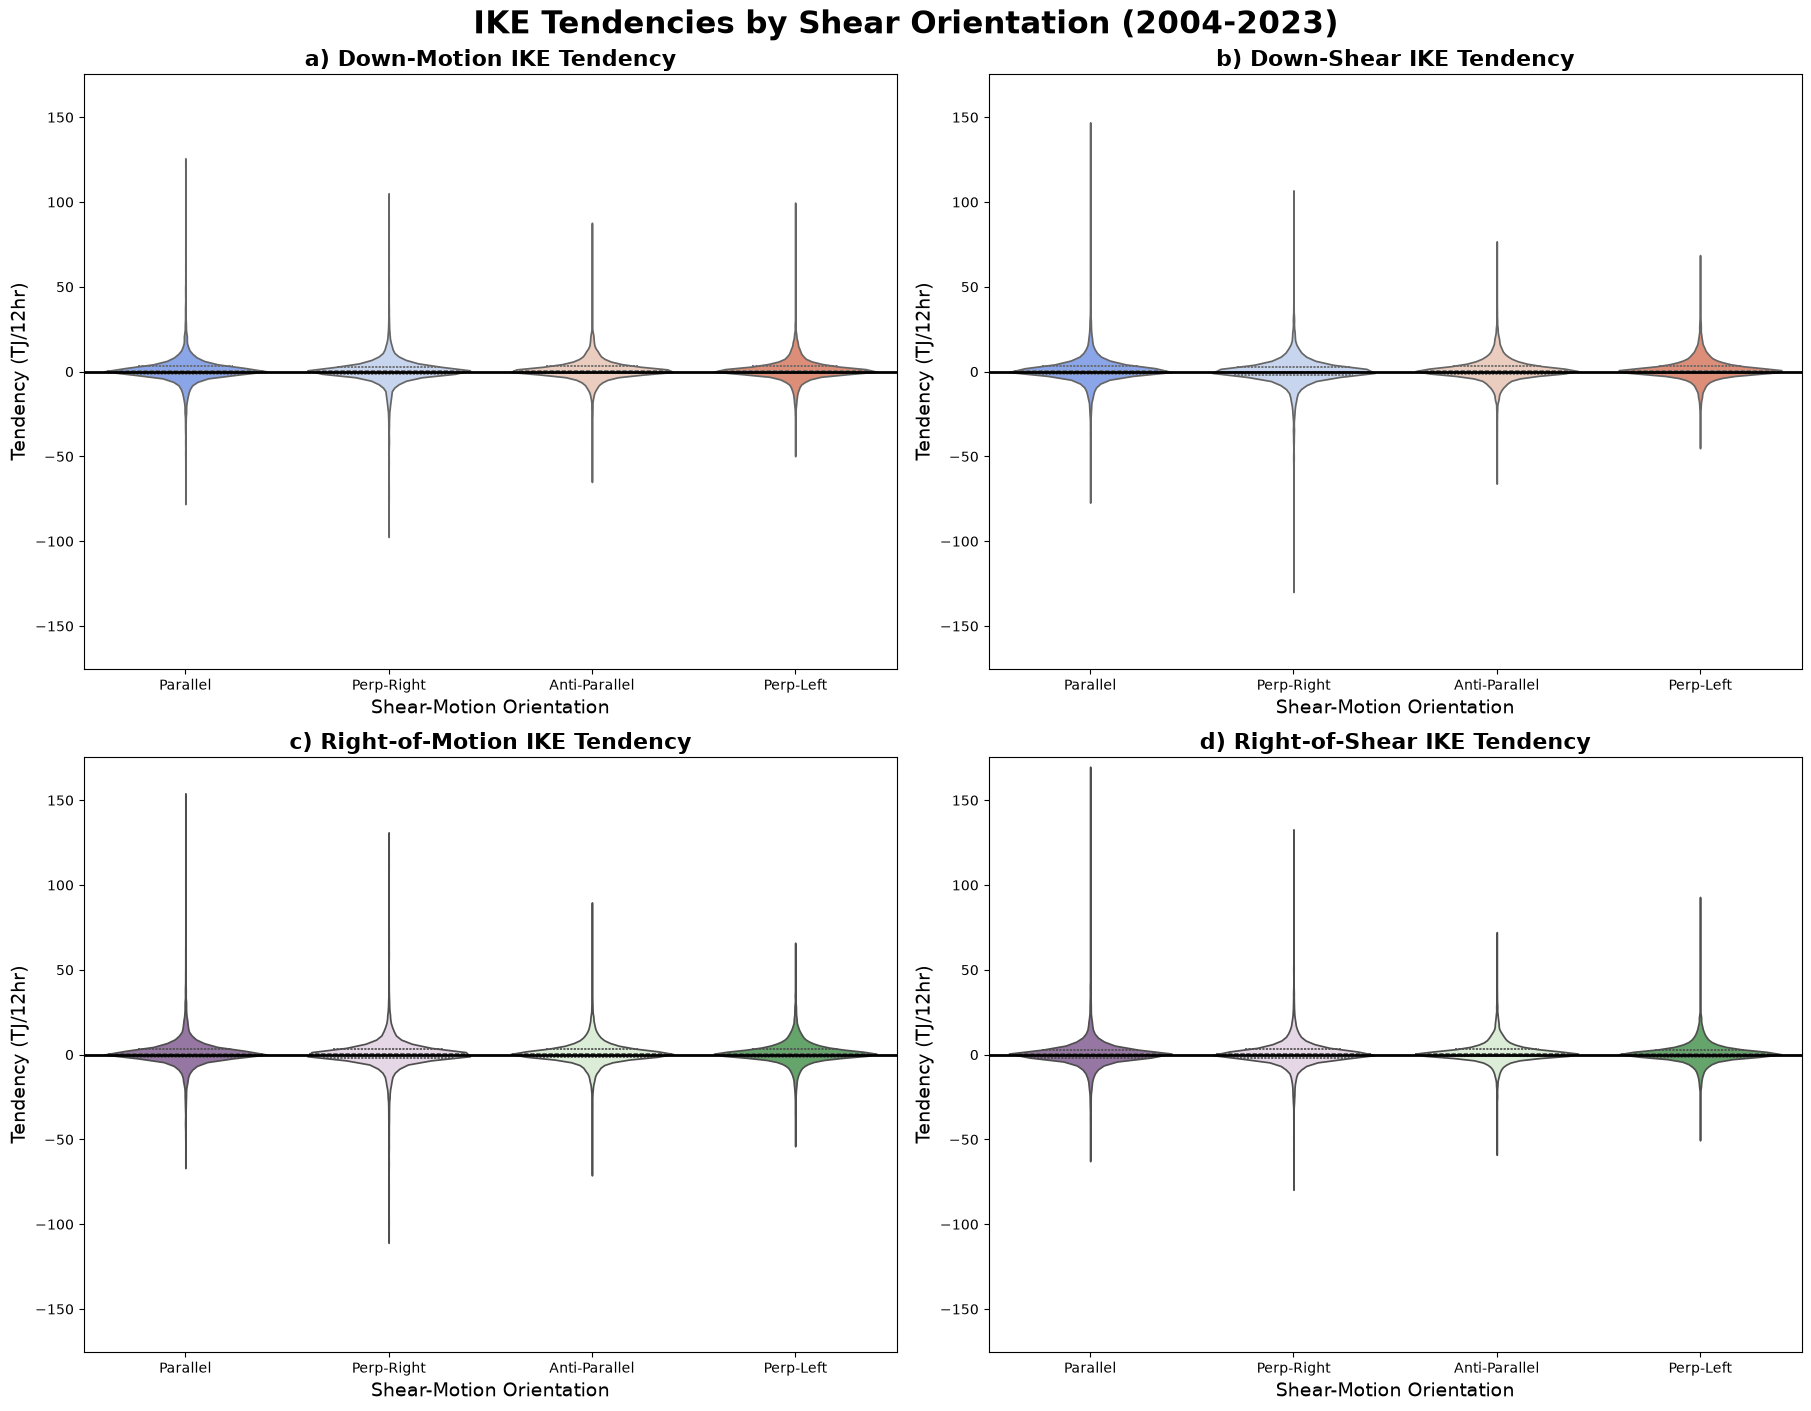

In [6]:
tendency_cols = ["front_motion_tendency", "down_shear_tendency", "right_motion_tendency", "right_shear_tendency"]
y_max = max(master_df[tendency_cols].abs().max()) * 1.05

fig = plt.figure(figsize=(18, 14), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)

ax_mid1 = fig.add_subplot(gs[0, 0])
sns.violinplot(x="shear_motion_orient", y="front_motion_tendency", data=master_df,
               order=ORIENT_ORDER, palette="coolwarm", inner="quartile", ax=ax_mid1)
ax_mid1.set_title("a) Down-Motion IKE Tendency", weight="bold", fontsize=16)

ax_mid2 = fig.add_subplot(gs[0, 1])
sns.violinplot(x="shear_motion_orient", y="down_shear_tendency", data=master_df,
               order=ORIENT_ORDER, palette="coolwarm", inner="quartile", ax=ax_mid2)
ax_mid2.set_title("b) Down-Shear IKE Tendency", weight="bold", fontsize=16)

ax_bot1 = fig.add_subplot(gs[1, 0])
sns.violinplot(x="shear_motion_orient", y="right_motion_tendency", data=master_df,
               order=ORIENT_ORDER, palette="PRGn", inner="quartile", ax=ax_bot1)
ax_bot1.set_title("c) Right-of-Motion IKE Tendency", weight="bold", fontsize=16)

ax_bot2 = fig.add_subplot(gs[1, 1])
sns.violinplot(x="shear_motion_orient", y="right_shear_tendency", data=master_df,
               order=ORIENT_ORDER, palette="PRGn", inner="quartile", ax=ax_bot2)
ax_bot2.set_title("d) Right-of-Shear IKE Tendency", weight="bold", fontsize=16)

for ax in (ax_mid1, ax_mid2, ax_bot1, ax_bot2):
    ax.axhline(0, color="black", linestyle="-", lw=2)
    ax.set_ylabel("Tendency (TJ/12hr)", fontsize=14)
    ax.set_xlabel("Shear-Motion Orientation", fontsize=14)
    ax.set_ylim(-y_max, y_max)

fig.suptitle(f"IKE Tendencies by Shear Orientation ({year_range[0]}-{year_range[1]})", fontsize=22, weight="bold")
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "asymmetry_tendencies.png"), dpi=300)
plt.show()
